In [12]:
import os
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Configure Plot Styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Define File Paths
CSV_PATH = os.path.join("..", "data", "processed", "nh58_features.csv")
GEOJSON_PATH = os.path.join("..", "data", "processed", "nh58_segments_features.geojson")
LANDSLIDE_PATH = os.path.join("..", "data", "raw", "landslide_inventory.geojson")

# Load Data
df = pd.read_csv(CSV_PATH)
gdf_segments = gpd.read_file(GEOJSON_PATH)
gdf_landslides = gpd.read_file(LANDSLIDE_PATH)

print(f"✅ Successfully loaded {len(df)} highway segments across {len(df)*0.5:.1f} km corridor.")
df.head()

✅ Successfully loaded 131 highway segments across 65.5 km corridor.


,segment_id,start_m,end_m,mean_elevation_m,mean_slope_deg,max_slope_deg,mean_aspect_deg,dist_to_landslide_m,dist_to_river_m
0,NH58_SEG_001,0.0,500.0,1866.2,22.8,47.8,177.8,4278.7,466.6
1,NH58_SEG_002,500.0,1000.0,1862.8,23.1,60.6,177.0,3778.7,465.7
2,NH58_SEG_003,1000.0,1500.0,1858.7,22.7,47.8,177.5,3278.7,464.7
3,NH58_SEG_004,1500.0,2000.0,1856.1,22.8,47.8,176.7,2778.7,464.0
4,NH58_SEG_005,2000.0,2500.0,1851.8,22.9,60.6,177.6,2278.7,462.9


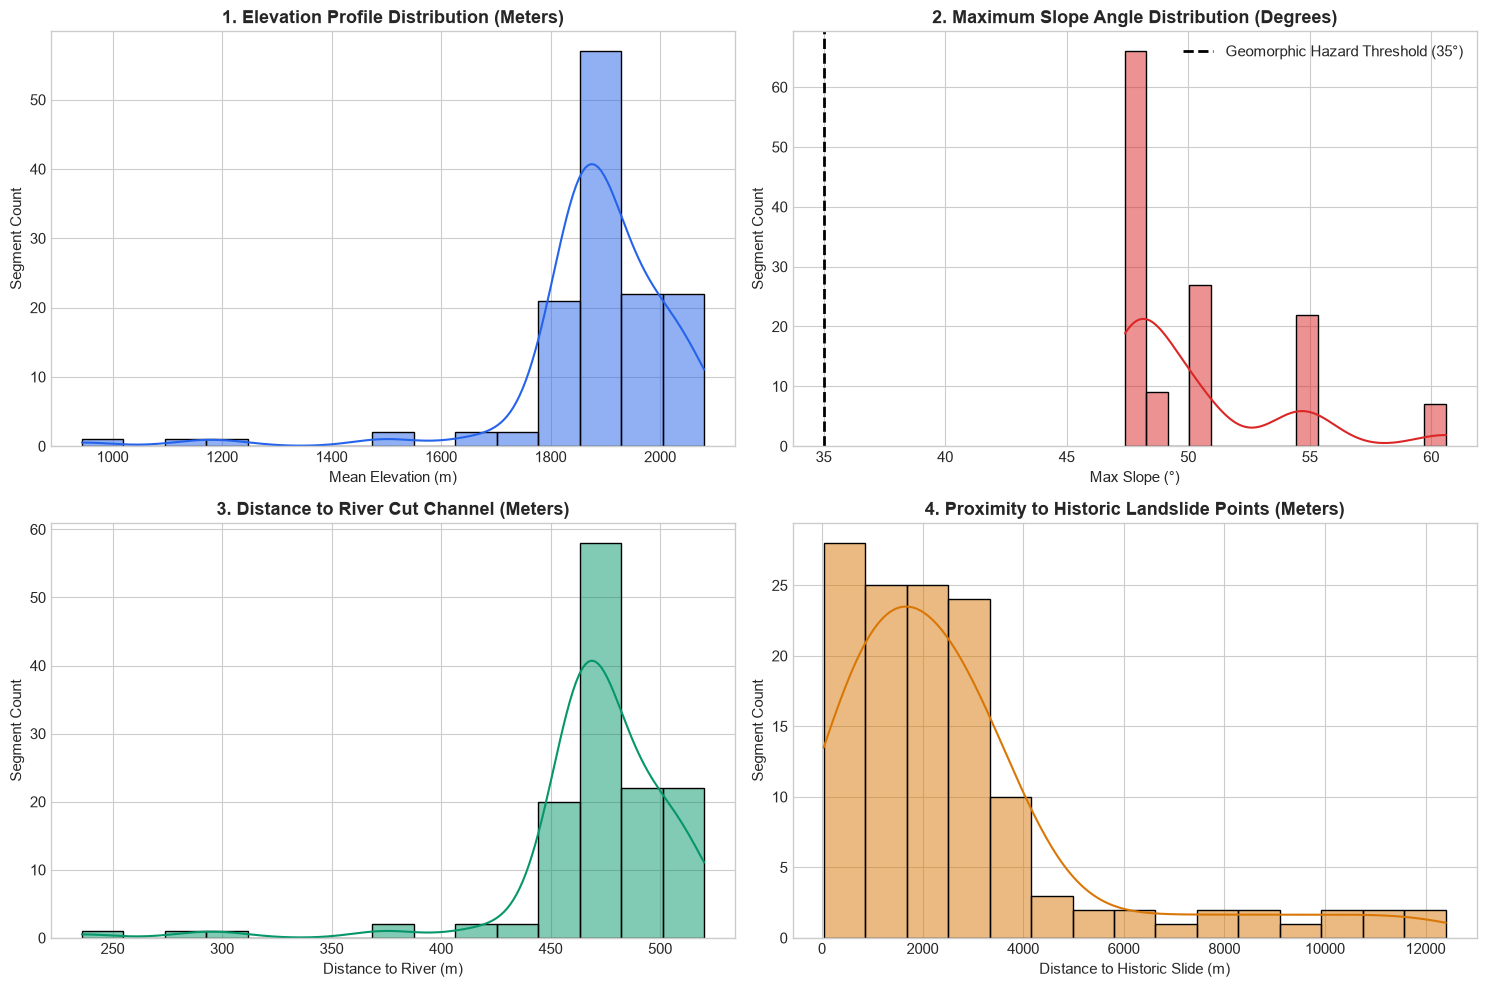

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Elevation Distribution along Alaknanda River Corridor
sns.histplot(df['mean_elevation_m'], kde=True, ax=axes[0, 0], color='#2563eb', bins=15)
axes[0, 0].set_title("1. Elevation Profile Distribution (Meters)", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("Mean Elevation (m)")
axes[0, 0].set_ylabel("Segment Count")

# 2. Maximum Slope Angle Distribution (Critical Failure Trigger)
sns.histplot(df['max_slope_deg'], kde=True, ax=axes[0, 1], color='#dc2626', bins=15)
axes[0, 1].axvline(x=35.0, color='black', linestyle='--', linewidth=2, label='Geomorphic Hazard Threshold (35°)')
axes[0, 1].set_title("2. Maximum Slope Angle Distribution (Degrees)", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("Max Slope (°)")
axes[0, 1].set_ylabel("Segment Count")
axes[0, 1].legend()

# 3. Proximity to Alaknanda River Cut
sns.histplot(df['dist_to_river_m'], kde=True, ax=axes[1, 0], color='#059669', bins=15)
axes[1, 0].set_title("3. Distance to River Cut Channel (Meters)", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Distance to River (m)")
axes[1, 0].set_ylabel("Segment Count")

# 4. Proximity to Historic Landslide Failures
sns.histplot(df['dist_to_landslide_m'], kde=True, ax=axes[1, 1], color='#d97706', bins=15)
axes[1, 1].set_title("4. Proximity to Historic Landslide Points (Meters)", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Distance to Historic Slide (m)")
axes[1, 1].set_ylabel("Segment Count")

plt.tight_layout()
plt.show()

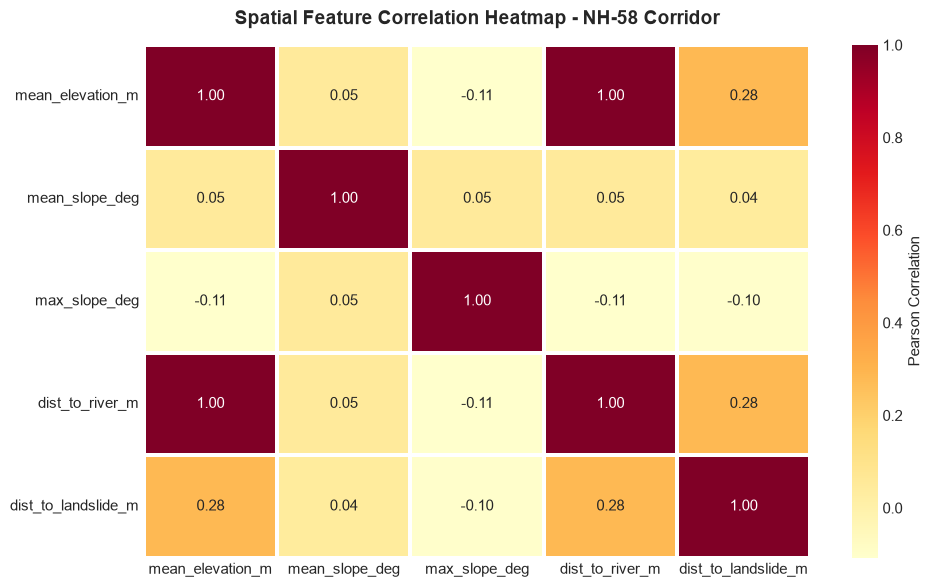

In [14]:
# Compute Correlation Matrix between static GIS factors
features = ['mean_elevation_m', 'mean_slope_deg', 'max_slope_deg', 'dist_to_river_m', 'dist_to_landslide_m']
corr = df[features].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='YlOrRd', fmt='.2f', linewidths=1.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title("Spatial Feature Correlation Heatmap - NH-58 Corridor", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

 Saved interactive HTML map to 'data/processed/nh58_eda_map.html'


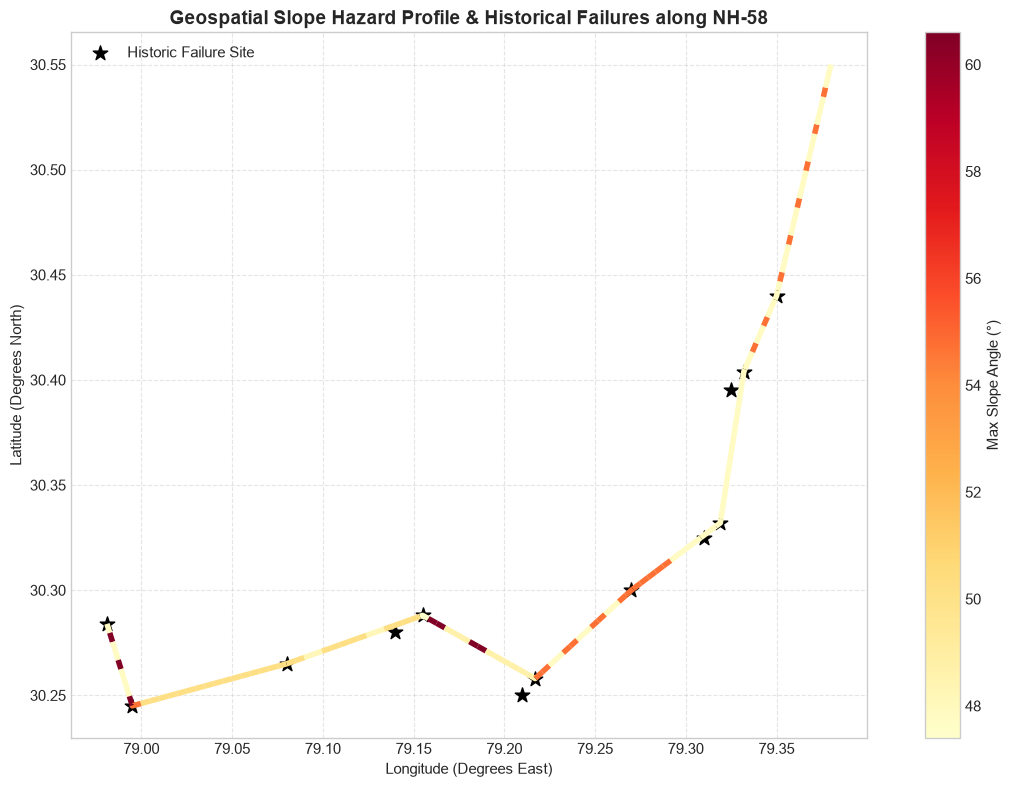

In [15]:
# 1. Save the interactive Folium map to disk (This will be served in our web dashboard later!)
m.save(os.path.join("..", "data", "processed", "nh58_eda_map.html"))
print(" Saved interactive HTML map to 'data/processed/nh58_eda_map.html'")

# 2. Render a robust, static Geospatial Matplotlib Plot (100% reliable in VS Code local view)
fig, ax = plt.subplots(figsize=(12, 8))

# Plot segments colored by max slope
gdf_segments.plot(
    column='max_slope_deg',
    cmap='YlOrRd',
    linewidth=4,
    legend=True,
    legend_kwds={'label': "Max Slope Angle (°)", 'orientation': "vertical"},
    ax=ax
)

# Overlay Historic Landslides as red stars
gdf_landslides.plot(ax=ax, color='black', marker='*', markersize=120, label='Historic Failure Site')

ax.set_title("Geospatial Slope Hazard Profile & Historical Failures along NH-58", fontsize=14, fontweight='bold')
ax.set_xlabel("Longitude (Degrees East)")
ax.set_ylabel("Latitude (Degrees North)")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()